# 02 · Basics

The **Introduction** notebook covered individual pulse sequences. This notebook shows how to repeat a sequence and vary its parameters. You will declare **variables**, define their values with **sweep sources**, and use **`average(shots)`** to average repeated measurements.

You will also retrieve, inspect, and plot measurement results. `qp.simulate` returns labelled arrays with dimensions and coordinates derived from the variables you sweep.

The worked examples demonstrate a single sweep, two nested sweeps, and two sweeps that advance together. They use simple measurement models on the reference platform.

As in **Introduction**, the examples use the waveform aliases `"readout"` and `"weights"`. They remain unresolved here because the reference platform generates data from the measurement model without evaluating the readout waveforms.

In [1]:
# Install QProgram if it is not already available in this Python environment.
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "qprogram[viz]==0.2.0"], check=True)
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.2.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np

import qprogram as qp
from qprogram import MeasurementField
from qprogram.buses import BusSchema
from qprogram.plotting import Quantity, Style
from qprogram.waveforms import IQDrag, IQZero, Square

schema = BusSchema.transmon()
q = schema.q

## 2.1 Variables

A variable represents a numeric value that can be assigned later or changed between iterations. Declare one when you want to reuse a program with different parameter values.

You can assign a value directly with `set_value()` and clear it with `reset()`. A sweep assigns successive values automatically. The example below demonstrates these changes before introducing loops.

In [3]:
scratch = qp.QProgram(label="variables", schema=schema)
amp = scratch.variable("amp")

print("initial value:   ", amp.value)
amp.set_value(0.25)  # Assign a value directly; a sweep does this for each iteration.
print("after set_value: ", amp.value)
amp.reset()
print("after reset:     ", amp.value)

initial value:    UNASSIGNED
after set_value:  0.25
after reset:      UNASSIGNED


### Declaring a variable

Use `program.variable(id, *, label=None, units=None, description=None)` to declare a variable. The `id` is required; the remaining arguments are optional and must be passed by keyword.

The identifier appears in the `.qp` file and names the corresponding result dimension when the variable is swept. It must match `[A-Za-z_][A-Za-z0-9_]*`, be unique within the program, and avoid the words in `qp.RESERVED_KEYWORDS`. Invalid or duplicate identifiers are rejected when you declare the variable.

Use `label` for a readable name and `units` for the unit of the values. Both are stored on the result coordinate and used to label plots automatically. The optional `description` provides further explanation in the saved program; it is not used for result or plot labels.

In [4]:
freq = scratch.variable(
    "freq", label="Readout frequency", units="Hz", description="Frequency used for the readout signal."
)

print("id / label / units:", freq.id, "|", freq.label, "|", freq.units)
print("declared variables:", [v.id for v in scratch.variables])

for bad_id, error in (("freq", qp.ValidationError), ("readout frequency", qp.InvalidVariableIdError)):
    try:
        scratch.variable(bad_id)
    except error as exc:
        print(f"\n{type(exc).__name__}:", exc)

id / label / units: freq | Readout frequency | Hz
declared variables: ['amp', 'freq']

ValidationError: Variable 'freq' is already declared on this QProgram

InvalidVariableIdError: Variable id 'readout frequency' is invalid: must match [A-Za-z_][A-Za-z0-9_]* (letters, digits, underscores only; cannot start with a digit, no spaces or special characters). Use the optional `label` for human-readable names.


## 2.2 Expressions

Operations on variables create symbolic expressions. They record the calculation to perform and are evaluated later using the variables' current values.

QProgram supports the following expression operations:

- Arithmetic: `+`, `-`, `*`, and `/`, including forms such as `2 * amp`. These create a `BinaryOp`. Power, floor division, and modulo are not supported.
- Unary operators: `-amp` and `+amp`, which create a `UnaryOp`.
- Mathematical functions: `abs()`, `qp.sin`, `qp.cos`, `qp.tan`, `qp.exp`, `qp.log`, `qp.sqrt`, `qp.minimum`, and `qp.maximum`, which create a `MathFunc`.
- Comparisons: `<`, `<=`, `>`, and `>=`, which create a `Comparison`. Use `qp.where(condition, then, else_)` to select a value based on a condition.
- Logical operators: `&`, `|`, and `~`, which create a `LogicalBinaryOp` or `LogicalNot`.

For symbolic equality and inequality between variables, use `qp.eq` and `qp.ne`. A variable's `==` operator returns a Python boolean for object comparison. The measurement state proxy has a different interface: it supports expressions such as `handle.state == 1`, used in **Advanced**.

A symbolic expression cannot be used as a Python truth value. For example, `if amp > 0.5:` raises `TypeError`, as shown below.

In [5]:
sketch = qp.QProgram(label="expressions", schema=schema)
detuning = sketch.variable("detuning", label="Detuning", units="Hz")

sketch.set_frequency(q[0].readout, detuning + 7.20e9)  # Store a symbolic frequency expression in the program.
sketch.wait(q[0].readout, 4 * detuning)

print(qp.dumps(sketch).split("body:")[1].rstrip())

try:
    if amp > 0.5:
        pass
except TypeError as exc:
    print("\nPython condition error:", exc)


  var detuning label="Detuning" units="Hz"

  set_frequency q[0].readout (detuning + 7200000000.0)
  wait q[0].readout (4 * detuning)

Python condition error: Expression has no truth value — use .evaluate()/.evaluate_or_raise() to compute it, or qprogram.where(cond, then, else_) to build a conditional expression.


### Using and evaluating expressions

Expressions can replace numeric arguments in operations such as `set_frequency`, `set_gain`, `set_phase`, `set_offset`, `set_parameter`, and `wait`.

They can also be used in numeric constructor arguments of parameterised waveforms. Exceptions include the sample array passed to `Arbitrary`, the waveform object passed to a wrapper, and the integer `buffer` of `FlatTop`.

To vary a pulse, pass the expression through its waveform constructor. The waveform evaluates the expression when `envelope()` is called. Section 2.8 uses this approach to sweep a pulse's amplitude.

Use `evaluate()` to inspect an expression's current value. It returns `qp.UNASSIGNED` if any required variable has no value. Use `evaluate_or_raise()` when evaluation must produce a number. The interpreter uses this stricter method during execution, so an unassigned variable raises an error.

In [6]:
tone = Square(amplitude=amp / 2, duration=8)
amp.set_value(0.8)
print("envelope with amp=0.8:", tone.envelope())
amp.reset()
print("amplitude expression after reset:", tone.amplitude.evaluate())

orphan = qp.QProgram(label="unbound", schema=schema)
loose = orphan.variable("loose")
orphan.set_gain(q[0].readout, loose)  # This variable remains unassigned when the program runs.
try:
    qp.simulate(orphan)
except qp.UnassignedVariableError as exc:
    print("\nexecution error:", exc)

envelope with amp=0.8: [0.4 0.4 0.4 0.4 0.4 0.4 0.4 0.4]
amplitude expression after reset: UNASSIGNED

execution error: Cannot evaluate expression Variable('loose'): unassigned variable(s) {Variable('loose')}


## 2.3 Sweeps

Use `program.sweep(variable, source)` to execute a block once for each value supplied by a source. Before each iteration, the sweep assigns the next value to the variable. Operations inside the block then use that value.

A **sweep source** defines the values and how they are generated. It is stored in the `.qp` file and declares the capabilities needed to execute it. The same `sweep` interface works with different sources, including ranges and explicit lists of values.

In [7]:
tiny = qp.QProgram(label="smallest_sweep", schema=schema)
gain = tiny.variable("gain")

with tiny.sweep(gain, qp.Values([0.1, 0.2, 0.3])):
    tiny.set_gain(q[0].readout, gain)

print(qp.dumps(tiny).split("body:")[1].rstrip())


  var gain

  for gain in [0.1, 0.2, 0.3]:
    set_gain q[0].readout gain


### Two ways to define a sweep

You can pass a source object to `sweep`, as above, or use a `from_*` builder method. For example, `sweep(gain).from_values([0.1, 0.2, 0.3])` creates the same sweep as passing `qp.Values([0.1, 0.2, 0.3])` directly.

The builder methods are resolved through the sweep-source registry, so registered extensions can provide additional `from_<name>` methods. Both forms create the same program structure and `.qp` text. Use whichever is clearer for your example; an explicit source object is useful when you want to reuse or inspect it.

Passing a plain list directly to `sweep` is not supported. Wrap it in `qp.Values` or use `from_values`, so the source can declare its type and required capabilities.

In [8]:
fluent = qp.QProgram(label="smallest_sweep", schema=schema)
g_fluent = fluent.variable("gain")
with fluent.sweep(g_fluent).from_values([0.1, 0.2, 0.3]):
    fluent.set_gain(q[0].readout, g_fluent)

print("same program structure:", tiny.body == fluent.body)
print("same text:", qp.dumps(tiny) == qp.dumps(fluent))

try:
    with tiny.sweep(gain, [0.1, 0.2, 0.3]):
        pass
except qp.ValidationError as exc:
    print("\nplain list validation error:", exc)

same program structure: True
same text: True

plain list validation error: Sweep source must be a SweepSource, got [0.1, 0.2, 0.3]


### Available sweep sources

QProgram provides eight sweep sources, each available as a source object or through the builder interface.

| Source | Purpose |
|---|---|
| `qp.Range(start, stop, step=1)` | Generate values with a specified step size. |
| `qp.Linspace(start, stop, num)` | Generate a specified number of evenly spaced values. |
| `qp.Values(points)` | Use explicit values supplied as an array-like object accepted by `numpy.asarray`. |
| `qp.Logspace(start, stop, num)` | Generate logarithmically spaced values between the supplied bounds, which are values rather than exponents. |
| `qp.File(path)` | Read values from a `.npy` file. The source stores the path and reads the file on each access. |
| `qp.Repeat(source, times)` | Repeat another source the specified number of times. |
| `qp.Rotate(source, by=1)` | Shift another source cyclically to the left. |
| `qp.Concat(sources)` | Concatenate several sources. |

`Repeat`, `Rotate`, and `Concat` combine or transform existing sources. Their outputs are also sources, so you can combine them further. The builder interface also supports chained `.rotate(by=...)` and `.repeat(...)` calls.

In [9]:
base = qp.Values([0.0, 0.5, 1.0])
sources = [
    qp.Range(0.0, 1.0, 0.25),
    qp.Linspace(0.0, 1.0, 5),
    qp.Logspace(0.01, 1.0, 5),
    qp.Repeat(base, 2),
    qp.Rotate(base, by=1),
    qp.Concat([base, qp.Linspace(2.0, 3.0, 3)]),
]

for source in sources:
    print(f"{type(source).__name__:9} {source.length():2d} points  {np.round(source.values(), 3)}")

chained = qp.QProgram(label="chained_source", schema=schema)
g_chain = chained.variable("gain")
with chained.sweep(g_chain).from_values([0.1, 0.2, 0.3]).rotate(by=1).repeat(2):
    chained.set_gain(q[0].readout, g_chain)

print("\nrotate by one position, then repeat twice:")
print(qp.dumps(chained).split("body:")[1].rstrip())

Range      5 points  [0.   0.25 0.5  0.75 1.  ]
Linspace   5 points  [0.   0.25 0.5  0.75 1.  ]
Logspace   5 points  [0.01  0.032 0.1   0.316 1.   ]
Repeat     6 points  [0.  0.5 1.  0.  0.5 1. ]
Rotate     3 points  [0.5 1.  0. ]
Concat     6 points  [0.  0.5 1.  2.  2.5 3. ]

rotate by one position, then repeat twice:

  var gain

  for gain in Repeat(source=Rotate(source=[0.1, 0.2, 0.3], by=1), times=2):
    set_gain q[0].readout gain


### Linear and arbitrary sources

Each source declares a `KIND` and a capability `TOKEN`. A platform can inspect these declarations before executing the program.

A source with `KIND="linear"` generates values of the form `start + step * i`. This allows a supporting instrument to generate the sequence from its start, step, and length. A source with `KIND="arbitrary"` supplies values through a table or through host communication.

`qp.Range` and `qp.Linspace` are linear sources. `qp.Values` is always arbitrary, even if its supplied values happen to be evenly spaced. Use a linear source when you want to declare that structure explicitly.

Source combinators are classified as arbitrary and include the capability requirements of their component sources. **Advanced** explains how platforms check these requirements.

`qp.Range` generates `round((stop - start) / step) + 1` points. Unlike Python's `range`, it can include `stop`; it reaches that value exactly when the step divides the interval evenly. Inspect `values()` when the interval is not an exact multiple of the step.

In [10]:
for source in (qp.Range(0.0, 1.0, 0.25), qp.Linspace(0.0, 1.0, 5), base, qp.Concat([base])):
    print(f"{type(source).__name__:9} {source.KIND:10} {sorted(source.tokens())}")

print("\nRange(0, 10, 2) includes stop:", qp.Range(0, 10, 2).values())
print("Range(0, 10, 3) ends below stop:", qp.Range(0, 10, 3).values())

try:
    qp.Range(0, 10, -2)  # Invalid: the step moves away from stop.
except qp.ValidationError as exc:
    print("\nsource validation error:", exc)

Range     linear     ['sweep.linear', 'sweep.range']
Linspace  linear     ['sweep.linear', 'sweep.linspace']
Values    arbitrary  ['sweep.arbitrary', 'sweep.values']
Concat    arbitrary  ['sweep.arbitrary', 'sweep.concat', 'sweep.values']

Range(0, 10, 2) includes stop: [ 0.  2.  4.  6.  8. 10.]
Range(0, 10, 3) ends below stop: [0. 3. 6. 9.]

source validation error: Range step -2.0 moves away from stop (0.0 -> 10.0); flip the step sign or swap the bounds


## 2.4 Measurement models

The reference platform calls a **measurement model** for each measurement at each shot and sweep point. The model receives the bus and an `env` mapping. This mapping contains currently assigned variable values, keyed by identifier, and platform parameter values, keyed as `"bus.parameter"`. Unassigned variables are absent from `env`.

`qp.MockMeasurementModel(response=None, p_excited=None, noise=0.0, raw_samples=16, seed=0)` provides a configurable model:

- `response` returns the noiseless complex I/Q value. The default is `0j`.
- `p_excited` returns the probability of state 1. By default, every shot is in state 0.
- `noise` sets the standard deviation of Gaussian noise added to each quadrature per shot.
- `raw_samples` sets the length of the simulated raw trace.
- `seed` initialises the model's random number generator. Creating a new model with the same seed reproduces the sequence; reusing an existing model continues its random sequence.

The example below records the arguments received by a response function during a nested sweep.

In [11]:
seen = []


def peek(bus, env):
    """Record the bus and variable values, then return a constant response."""
    seen.append((str(bus), dict(env)))
    return 1 + 0j


probe = qp.QProgram(label="env_probe", schema=schema)
p_amp = probe.variable("ro_amp", units="DAC units")
p_freq = probe.variable("ro_freq", units="Hz")

with probe.average(shots=2):
    with probe.sweep(p_amp, qp.Values([0.1, 0.4])):
        with probe.sweep(p_freq, qp.Linspace(7.19e9, 7.21e9, 3)):
            probe.measure(q[0].readout, "readout", "weights")

qp.simulate(probe, model=qp.MockMeasurementModel(response=peek))

print("samples requested:", len(seen), "= 2 shots x 2 amplitudes x 3 frequencies")
print("bus:", seen[0][0])
print("env:", seen[0][1])

samples requested: 12 = 2 shots x 2 amplitudes x 3 frequencies
bus: q0/readout
env: {'ro_amp': 0.1, 'ro_freq': 7190000000.0}


### Defining a custom model

To define your own measurement model, implement `sample(bus, env)` and return a `qp.MeasurementSample`. The sample contains `i`, `q`, `state`, and an optional `raw` trace. If your model returns raw traces, provide a `raw_samples` attribute so the executor can determine their length at the start of the run.

A custom model is useful when measurements depend on earlier samples, share state across buses, or require a relationship between the classified state and I/Q values. The example below chooses the state first, then samples I/Q values from the distribution associated with that state.

In [12]:
class TwoStateReadout:
    """Sample I/Q values from a distribution selected by the sampled qubit state."""

    def __init__(self, p_excited, seed=0):
        self.p_excited = p_excited
        self.rng = np.random.default_rng(seed)

    def sample(self, bus, env):
        state = int(self.rng.random() < self.p_excited(bus, env))
        centre_i, centre_q = (0.9, 0.1) if state else (0.2, -0.3)
        spread = self.rng.normal(0.0, 0.08, 2)
        return qp.MeasurementSample(i=centre_i + spread[0], q=centre_q + spread[1], state=state)


one_point = qp.QProgram(label="own_model", schema=schema)
m_own = one_point.measure(
    q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE)
)
own = qp.simulate(one_point, model=TwoStateReadout(lambda bus, env: 1.0, seed=1))

print("I/Q sample for state 1:", np.round(own.get(m_own).values, 3))
print("classified state:     ", float(own.get(m_own, field=MeasurementField.STATE)))

I/Q sample for state 1: [0.966 0.126]
classified state:      1.0


## 2.5 Averaging measurements

Use `with program.average(shots=N):` to repeat a block `N` times and average its measurement outputs. Integrated I/Q values and raw traces are averaged over the shots. Classified states are averaged to estimate the probability of state 1.

Averaging does not add a shot dimension to the result. It does, however, add a level of loop nesting. A platform's `max_loop_nesting` capability therefore applies to averaging blocks as well as sweeps, as explained in **Advanced**.

The example below compares the same 64-point scan with different shot counts.

In [13]:
def flat_scan(shots):
    """Measure a constant noisy signal at 64 points, averaging `shots` per point."""
    program = qp.QProgram(label=f"flat_{shots}", schema=schema)
    index = program.variable("idx")
    with program.average(shots=shots):
        with program.sweep(index, qp.Range(0, 63, 1)):
            handle = program.measure(q[0].readout, "readout", "weights")
    model = qp.MockMeasurementModel(response=lambda bus, env: 1 + 0j, noise=0.5, seed=5)
    return qp.simulate(program, model=model).get(handle)


for shots in (1, 4, 64, 256):
    scan = flat_scan(shots)
    print(f"shots={shots:4d}  dims={scan.dims}  shape={scan.shape}  "
          f"std(I)={scan.sel(IQ='I').values.std():.4f}")

shots=   1  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.5473
shots=   4  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.2596
shots=  64  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0664


shots= 256  dims=('idx', 'IQ')  shape=(64, 2)  std(I)=0.0305


The result dimensions and shape stay the same for every shot count. Increasing the number of shots reduces the variation in the averaged signal. For independent noise, the standard deviation of the mean decreases approximately as `1 / sqrt(shots)`.

For `MeasurementField.STATE`, one shot produces a value of 0 or 1 at each point. Averaging many shots produces a fraction between 0 and 1. The next example compares these two cases using a model with a state-1 probability of 0.3. Both results have the same shape.

In [14]:
def population_scan(shots):
    """Estimate a state-1 probability of 0.3 at five points with `shots` per point."""
    program = qp.QProgram(label=f"pop_{shots}", schema=schema)
    rep = program.variable("rep")
    with program.average(shots=shots):
        with program.sweep(rep, qp.Range(0, 4, 1)):
            handle = program.measure(
                q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,)
            )
    biased = qp.MockMeasurementModel(p_excited=lambda bus, env: 0.3, seed=9)
    return qp.simulate(program, model=biased).get(handle, field=MeasurementField.STATE)


print("shots=1   ->", population_scan(1).values, "  one classified shot per point")
print("shots=500 ->", population_scan(500).values, "  estimated state-1 probability per point")

shots=1   -> [0. 1. 0. 0. 0.]   one classified shot per point
shots=500 -> [0.27  0.318 0.308 0.258 0.304]   estimated state-1 probability per point


## 2.6 One swept variable

This example combines a variable, a sweep, averaging, and a measurement model. It sweeps the readout frequency from 7.19 to 7.21 GHz in 200 kHz steps and averages 200 shots at each point.

The `s21` response function uses two constants to describe the simulated resonator. `F_READOUT` is its assumed true resonance frequency, set to 7.20 GHz. `KAPPA` is its linewidth parameter in hertz, set to 1.5 MHz. We define both next to the model so their meaning is clear.

`ro_freq` is the frequency varied by the program, while `F_READOUT` stays fixed in the model. Later, we will compare the frequency estimated from the simulated measurements with this known reference value.

In [15]:
F_READOUT = 7.20e9  # Hz; true resonator frequency assumed by the mock model.
KAPPA = 1.5e6  # Hz; resonator linewidth parameter.


def s21(bus, env):
    """Return a transmission response centred at F_READOUT with linewidth KAPPA."""
    delta = (env["ro_freq"] - F_READOUT) / (KAPPA / 2)
    return 1.0 - 0.9 / (1.0 + 1j * delta)


spectroscopy = qp.QProgram(
    label="resonator_spectroscopy", description="Sweep the readout frequency and average the integrated response.", schema=schema
)
ro_freq = spectroscopy.variable("ro_freq", label="Readout frequency", units="Hz")

with spectroscopy.average(shots=200):
    with spectroscopy.sweep(ro_freq, qp.Range(7.19e9, 7.21e9, 0.2e6)):
        spectroscopy.set_frequency(q[0].readout, ro_freq)
        m_spec = spectroscopy.measure(q[0].readout, "readout", "weights")

print(qp.dumps(spectroscopy))

#!QProgram 0.2

metadata:
  label: "resonator_spectroscopy"
  description: "Sweep the readout frequency and average the integrated response."

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 200:
    for ro_freq in Range(start=7190000000.0, stop=7210000000.0, step=200000.0):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



In [16]:
result = qp.simulate(spectroscopy, model=qp.MockMeasurementModel(response=s21, noise=0.02, seed=7))
iq = result.get(m_spec)

print("dims:", iq.dims, "shape:", iq.shape)

dims: ('ro_freq', 'IQ') shape: (101, 2)


The array has 101 frequency points and two quadratures. The 200 shots have been averaged at each point, so there is no shot dimension.

### Understanding the result object

`qp.simulate` returns a `qp.QProgramResult`. It contains one record for each `measure` operation, in declaration order. Each record identifies the bus, measurement name, and requested output fields.

In [17]:
print(result)
for record in result.measurements:
    print("  ", record.bus, record.name, sorted(record.fields))

QProgramResult(1 measurements, names=['q0/readout/m0'])
   q0/readout q0/readout/m0 ['iq']


Use `result.get(measurement, bus=None, field=MeasurementField.IQ)` to retrieve one output array. The first argument accepts three forms:

- A measurement handle, such as `m_spec`, returned by `measure`.
- A measurement name, useful when loading a saved program without its original Python variables.
- An integer index selecting a record by declaration order.

Use `bus=` to filter records by bus before resolving the measurement. `result.plot` accepts the same selection arguments.

The default field is `MeasurementField.IQ`. Requesting a field that was not included in the `measure` call raises `KeyError`. For example, a measurement requesting only `MeasurementField.STATE` must also specify that field when retrieving its result.

The returned `xarray.DataArray` has a dimension for each enclosing sweep, ordered from outermost to innermost. Variable identifiers name the dimensions, and swept values provide their coordinates. An integrated result also has an `IQ` dimension of length two. Variable labels and units are stored as coordinate attributes and used when plotting.

In [18]:
print("by handle:", result.get(m_spec).shape,
      "| by name:", result.get("q0/readout/m0").shape,
      "| by position:", result.get(0).shape)
print("coordinate metadata:", iq.coords["ro_freq"].attrs)

# Select the I quadrature at the sampled frequency nearest the model's resonance.
on_resonance = iq.sel(IQ="I").sel(ro_freq=F_READOUT, method="nearest")
print("I at the resonator:", round(float(on_resonance), 4))

try:
    # This measurement requested only MeasurementField.IQ.
    result.get(m_spec, field=MeasurementField.STATE)
except KeyError as exc:
    print("unrequested field error:", exc)

by handle: (101, 2) | by name: (101, 2) | by position: (101, 2)
coordinate metadata: {'long_name': 'Readout frequency', 'units': 'Hz'}
I at the resonator: 0.1005
unrequested field error: "Measurement 'q0/readout/m0' has no field 'state'; available: iq"


### Inspecting values in the result

Use the coordinate values and measured data together to extract information from a scan. Below, we combine I and Q into a complex response, calculate its magnitude, and use `argmin()` to select the frequency with the lowest value.

This selects one of the sampled frequencies. A finer sweep or a fitted model can provide a more precise estimate; noise also affects which point is selected.

In [19]:
freqs = iq.coords["ro_freq"].values
magnitude = np.abs(iq.sel(IQ="I").values + 1j * iq.sel(IQ="Q").values)
f_dip = freqs[magnitude.argmin()]

print(f"sampled minimum: {f_dip / 1e9:.6f} GHz")
print(f"model centre:    {F_READOUT / 1e9:.6f} GHz")
print(f"frequency spacing: {(freqs[1] - freqs[0]) / 1e3:.0f} kHz")

sampled minimum: 7.200000 GHz
model centre:    7.200000 GHz
frequency spacing: 200 kHz


## 2.7 Plotting results

`result.plot(handle)` retrieves a measurement and chooses a plot from its dimensions. One sweep dimension produces a line plot; two produce a heatmap. Axis labels and units come from the variable metadata stored in the result.

By default, an integrated result displays both I and Q. Use `channels="magnitude"` to plot the magnitude of the complex response or `channels="phase"` to plot its phase. The value-axis label updates to match your selection.

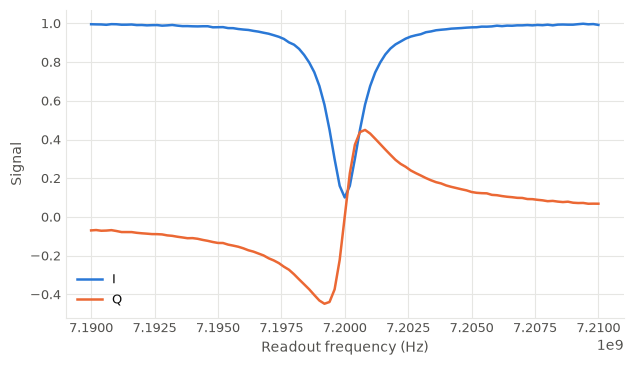

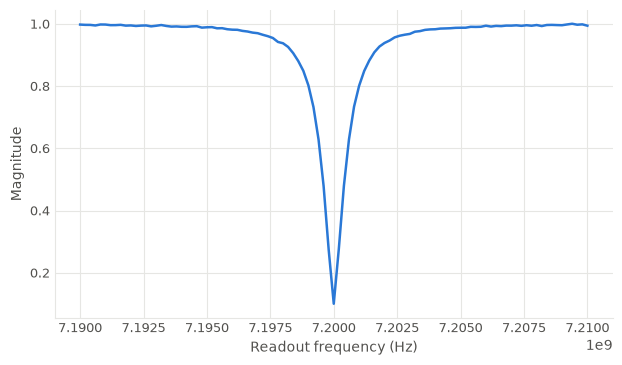

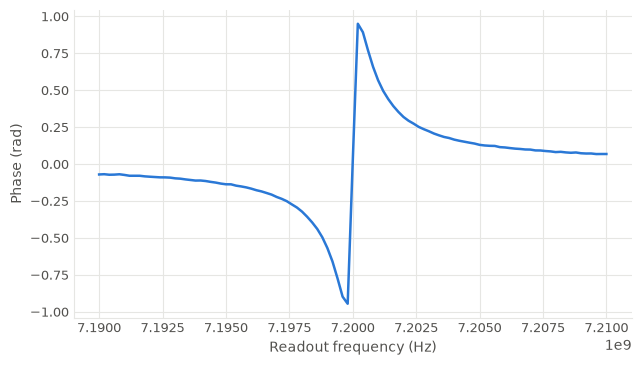

In [20]:
result.plot(m_spec)
plt.show()

result.plot(m_spec, channels="magnitude")
plt.show()

result.plot(m_spec, channels="phase")
plt.show()

You can customise a plot through its arguments and the returned Matplotlib `Axes`.

Use `coords=` to change how coordinates are displayed without modifying the stored data. Each entry maps a coordinate name to a `Quantity(label, units, transform)`. For example, displaying frequency in gigahertz requires both `units="GHz"` and a transform that divides the values by `1e9`.

For coordinates that already declare units, provide the new units and the conversion together. Changing only one would make the values and label inconsistent, so the plotting interface rejects it. The following cells demonstrate both errors.

Use `value=` to customise the measured quantity and `style=` for presentation options. Here, `Style(markers=True)` adds a marker at each sample. Any reference lines added through the returned axes must also use the displayed units, so both frequency markers below are expressed in gigahertz.

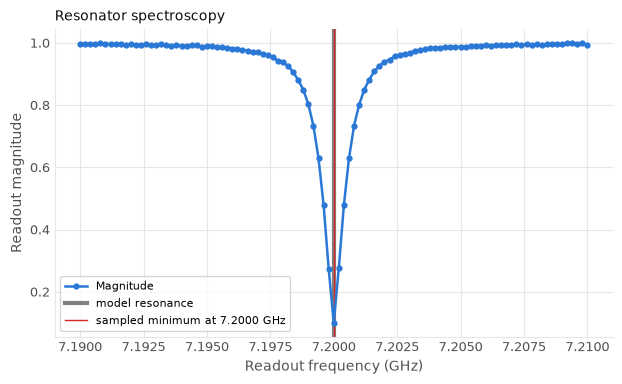

In [21]:
ax = result.plot(
    m_spec,
    channels="magnitude",
    coords={"ro_freq": Quantity(units="GHz", transform=lambda v: v / 1e9)},
    value=Quantity("Readout magnitude"),
    style=Style(markers=True),
    title="Resonator spectroscopy",
)
ax.axvline(F_READOUT / 1e9, color="grey", lw=3, label="model resonance")
ax.axvline(f_dip / 1e9, color="tab:red", lw=1, label=f"sampled minimum at {f_dip / 1e9:.4f} GHz")
ax.legend(fontsize=8)
plt.show()

In [22]:
try:
    result.plot(m_spec, coords={"ro_freq": Quantity(transform=lambda v: v / 1e9)})
except qp.ValidationError as exc:
    print(exc, "\n")

try:
    result.plot(m_spec, coords={"ro_freq": Quantity(units="GHz")})
except qp.ValidationError as exc:
    print(exc)

coords['ro_freq'] rescales the values, so the inherited unit 'Hz' no longer describes them and the axis would read (Hz) over numbers that are not in Hz. Pass units= for what they are now, units='' if they are now a bare ratio, or units='Hz' if the transform leaves the unit alone, as subtracting a baseline does. 

coords['ro_freq'] relabels the unit from 'Hz' to 'GHz' without changing the numbers, so the axis would read (GHz) over values still in Hz. Pass the transform= that converts them, or correct the unit on the variable the coordinate came from.


## 2.8 Two nested sweeps

Nest two `with program.sweep(...)` blocks to measure every combination of their values. The outer sweep becomes the first result dimension, and the inner sweep becomes the second.

This example sweeps 21 drive amplitudes and 41 frequencies, producing 861 points. With 200 shots at each point, the model is sampled 172,200 times.

The amplitude variable is passed to the waveform constructor, while the frequency variable is passed to `set_frequency`. This demonstrates the two ways to use variables introduced in section 2.2.

The `p_saturated` function provides a simple Lorentzian response. `F_01` is the assumed true qubit transition frequency, set to 4.85 GHz. `RABI_RATE` converts drive amplitude into a rotation rate, using 40 MHz per DAC unit. In this model, that rate sets the response width, so increasing the amplitude broadens the resonance while its maximum population remains 0.5.

We define these constants beside the model and reuse them when setting the sweep range, displaying frequency offsets, and comparing the estimated width with the model prediction.

In [23]:
F_01 = 4.85e9  # Hz; true qubit transition frequency assumed by the mock model.
RABI_RATE = 40e6  # Hz per DAC unit; converts amplitude to the model's rotation rate.


def p_saturated(bus, env):
    """Return a Lorentzian population response using the swept amplitude and frequency."""
    rabi = RABI_RATE * env["drive_amp"]
    return 0.5 * rabi**2 / (rabi**2 + (env["drive_freq"] - F_01) ** 2)


two_tone = qp.QProgram(label="qubit_spectroscopy", description="Sweep drive amplitude and frequency, then average the classified state.", schema=schema)
drive_amp = two_tone.variable("drive_amp", label="Drive amplitude", units="DAC units")
drive_freq = two_tone.variable("drive_freq", label="Drive frequency", units="Hz")

with two_tone.average(shots=200):
    with two_tone.sweep(drive_amp, qp.Linspace(0.05, 0.30, 21)):
        with two_tone.sweep(drive_freq, qp.Linspace(F_01 - 20e6, F_01 + 20e6, 41)):
            two_tone.set_frequency(q[0].drive, drive_freq)
            two_tone.play(q[0].drive, IQZero(Square(amplitude=drive_amp, duration=20_000)))
            two_tone.sync([q[0].drive, q[0].readout])
            m_two_tone = two_tone.measure(
                q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,)
            )

print("points:", 21 * 41, "at 200 shots =", 21 * 41 * 200, "samples")

points: 861 at 200 shots = 172200 samples


In [24]:
map_result = qp.simulate(two_tone, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
population = map_result.get(m_two_tone, field=MeasurementField.STATE)

print("dims:", population.dims, "shape:", population.shape, "(outermost sweep first)")

dims: ('drive_amp', 'drive_freq') shape: (21, 41) (outermost sweep first)


With two sweep dimensions, `result.plot` produces a heatmap. By default, the inner sweep is shown on the horizontal axis and the outer sweep on the vertical axis. Here, these are frequency and amplitude. The colour represents the excited-state population.

Use `x=` or `y=` to select an axis explicitly; the other dimension is assigned to the remaining axis.

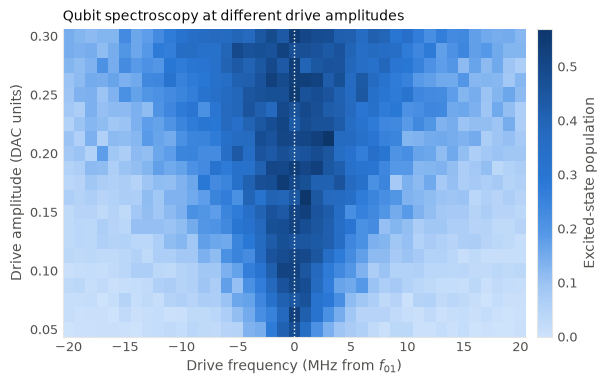

In [25]:
ax_map = map_result.plot(
    m_two_tone,
    field=MeasurementField.STATE,
    coords={"drive_freq": Quantity("Drive frequency", "MHz from $f_{01}$", lambda v: (v - F_01) / 1e6)},
    value=Quantity("Excited-state population"),
    title="Qubit spectroscopy at different drive amplitudes",
)
ax_map.axvline(0.0, color="w", ls=":", lw=1)
plt.show()

You can also analyse individual rows of the result array. The example below estimates the response width by finding frequencies whose population is at least 0.25, half the model's peak of 0.5.

For this model, the full width at half maximum is `2 * RABI_RATE * amplitude` in hertz. We compare that value with the width estimated from the sampled data.

In [26]:
amps = population.coords["drive_amp"].values
scan = population.coords["drive_freq"].values
rows = population.values

print("amplitude   estimated width   model width")
for row in (0, 10, 20):
    above = scan[rows[row] >= 0.25]  # Half of the model peak population, which is 0.5.
    print(f"    {amps[row]:.3f}      {(above[-1] - above[0]) / 1e6:5.1f} MHz"
          f"          {2 * RABI_RATE * amps[row] / 1e6:5.1f} MHz")

amplitude   estimated width   model width
    0.050        3.0 MHz            4.0 MHz
    0.175       14.0 MHz           14.0 MHz
    0.300       24.0 MHz           24.0 MHz


The estimated widths are affected by both the 1 MHz frequency spacing and the noise from a finite number of shots. A threshold-based estimate uses the sampled frequencies without interpolation, which is particularly limiting for the narrower responses.

## 2.9 Sweeping two variables together

Nested sweeps visit every combination of values. To use pairs of values instead, combine sweeps with `|`:

`program.sweep(a, source_a) | program.sweep(b, source_b)`

The combined block assigns the next value to both variables and executes its shared body once per pair. All sources must have the same length. This requirement is checked when entering the `with` block, rather than when creating the combined sweep object. You can chain more sweeps with additional `|` operators.

The resulting block is a `Parallel` node. Its `.loops` attribute contains the component loops, and `.elements` contains their shared body.

In the result, the variables share one dimension named by joining their identifiers, such as `"a|b"`. Each variable retains its own coordinate array along that dimension. The values at position `k` are paired, so the result does not form a two-dimensional grid.

In [27]:
mismatched = qp.QProgram(label="mismatched", schema=schema)
a = mismatched.variable("a")
b = mismatched.variable("b")

pair_of_loops = mismatched.sweep(a, qp.Linspace(0, 1, 5)) | mismatched.sweep(b, qp.Linspace(0, 1, 6))
print("Combined sweep created; source lengths are checked when entering the block.")

try:
    with pair_of_loops:
        pass
except qp.ValidationError as exc:
    print("validation error on block entry:", exc)

Combined sweep created; source lengths are checked when entering the block.
validation error on block entry: parallel loops must have the same number of iterations to advance in lockstep; got Sweep('a'): 5, Sweep('b'): 6


The next example selects the frequency with the highest measured population at each amplitude in the previous map. It then pairs those frequencies with their amplitudes in a combined sweep.

This new sweep has 21 points, compared with 861 in the original map. It demonstrates how values extracted from one result can define the sources for a later program. We reuse `p_saturated` with the same `F_01` and `RABI_RATE` values, so both programs measure the same simulated response.

In [28]:
ridge_freqs = scan[rows.argmax(axis=1)]

ridge = qp.QProgram(label="qubit_ridge", schema=schema)
r_amp = ridge.variable("drive_amp", label="Drive amplitude", units="DAC units")
r_freq = ridge.variable("drive_freq", label="Drive frequency", units="Hz")

with ridge.average(shots=200):
    with ridge.sweep(r_amp, qp.Values(amps)) | ridge.sweep(r_freq, qp.Values(ridge_freqs)):
        ridge.set_frequency(q[0].drive, r_freq)
        ridge.play(q[0].drive, IQZero(Square(amplitude=r_amp, duration=20_000)))
        ridge.sync([q[0].drive, q[0].readout])
        m_ridge = ridge.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,))

In [29]:
ridge_result = qp.simulate(ridge, model=qp.MockMeasurementModel(p_excited=p_saturated, seed=11))
ridge_pop = ridge_result.get(m_ridge, field=MeasurementField.STATE)

print("dims:  ", ridge_pop.dims, ridge_pop.shape)
print("coords:", list(ridge_pop.coords))
print("sweep points:", ridge_pop.sizes["drive_amp|drive_freq"], "compared with", 21 * 41, "in the nested sweep")
print("lowest population at the selected frequencies:", round(float(ridge_pop.min()), 3), "(model peak: 0.5)")

dims:   ('drive_amp|drive_freq',) (21,)
coords: ['drive_amp', 'drive_freq']
sweep points: 21 compared with 861 in the nested sweep
lowest population at the selected frequencies: 0.435 (model peak: 0.5)


For a combined sweep, the default plot displays the first variable on the bottom axis and the second on a top axis. Both axes use the same sample positions. The top labels can repeat when several paired points have the same frequency.

You can customise each coordinate independently through `coords=`. Below, the amplitude keeps its original units, while frequency is displayed as an offset from `F_01` in megahertz.

The model predicts a population of 0.5 at resonance. The plotted values vary around the response at the selected frequencies because each point averages a finite number of shots. A horizontal reference line marks 0.5, and fixed vertical limits make the variation easier to assess.

To display only one coordinate axis, select it with `x=`. Once a coordinate is omitted from the plot, including it in `coords=` raises a validation error.

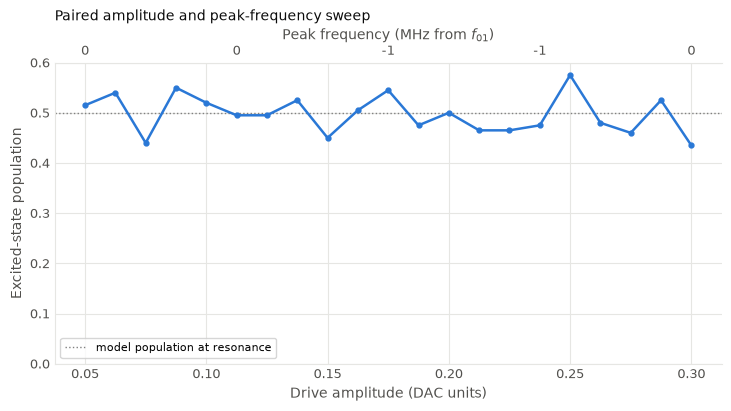

coords['drive_freq'] names a coordinate this figure does not draw. This line draws: 'drive_amp' (the x axis). The measured quantity is not keyed here — name it with value=Quantity(...). Coordinates on this result: drive_amp, drive_freq.


In [30]:
ax_ridge = ridge_result.plot(
    m_ridge,
    field=MeasurementField.STATE,
    coords={"drive_freq": Quantity("Peak frequency", "MHz from $f_{01}$", lambda v: (v - F_01) / 1e6)},
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="Paired amplitude and peak-frequency sweep",
)
ax_ridge.set_ylim(0.0, 0.6)
ax_ridge.axhline(0.5, color="grey", ls=":", lw=1, label="model population at resonance")
ax_ridge.legend(fontsize=8)
plt.show()

try:
    ridge_result.plot(m_ridge, field=MeasurementField.STATE, x="drive_amp",
                      coords={"drive_freq": Quantity(units="Hz")})
except qp.ValidationError as exc:
    print(exc)

### 🧩 Exercise 2.1

Create a program that sweeps the amplitude of a drive pulse at a fixed frequency. Use the result to estimate the amplitude of a pi pulse and plot the measured population.

The supplied `p_rabi` model produces a sine-squared response. Its constant `A_PI`, defined beside the function, is the assumed true pi-pulse amplitude in DAC units. We set it to 0.62 and use it both to generate the mock data and to check the estimate. The model provides measurement values without simulating the pulse dynamics.

1. Create a program labelled `rabi` using the existing `schema`. Declare an amplitude variable with the identifier `amp`, a readable label, and `units="DAC units"`. The model accesses this variable as `env["amp"]`.
2. Use `average(shots=200)` around a linear sweep of 41 amplitudes from 0.0 to 1.0.
3. Inside the sweep, set the drive frequency to `F_01`, the qubit frequency defined in section 2.8. Play an `IQDrag` waveform with the variable as its amplitude, `duration=40`, `sigma=10`, and `beta=0.15`.
4. Synchronise the drive and readout buses. Measure the readout bus using the aliases `"readout"` and `"weights"`, requesting only `MeasurementField.STATE`. Store the measurement handle.
5. Simulate the program with `qp.MockMeasurementModel(p_excited=p_rabi, seed=17)`. Retrieve the state result and print its dimensions and shape.
6. Get the amplitudes from this result's `amp` coordinate. Restrict them to values at or below 0.5, find the amplitude whose population is closest to 0.5, and double it to estimate the pi-pulse amplitude. Compare the estimate with `A_PI`. Use this result's coordinate rather than `amps`, which contains values from the earlier nested sweep.
7. Plot the population with a marker at each sample and a descriptive value-axis label. Add a dashed vertical line at the estimated pi-pulse amplitude using the returned axes.

The estimate in step 6 uses the rising part of the sine-squared curve. At population 0.5, the slope is steeper than at the peak, making the amplitude less sensitive to small population changes. The finite sweep spacing and measurement noise still affect the estimate. No coordinate conversion is needed because the amplitude variable already declares DAC units.

In [31]:
A_PI = 0.62  # DAC units; true pi-pulse amplitude assumed by the mock model.


def p_rabi(bus, env):
    """Return a sine-squared population response with its first maximum at A_PI."""
    return np.sin(np.pi * env["amp"] / (2 * A_PI)) ** 2

dims: ('amp',) shape: (41,)
population 0.5 at amplitude 0.300; estimated pi-pulse amplitude 0.600
model pi-pulse amplitude 0.620, amplitude spacing 0.025


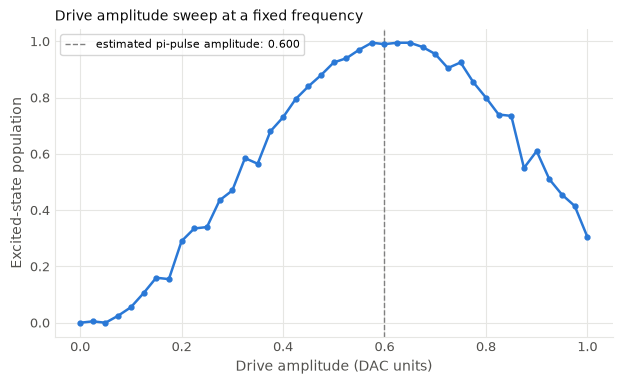

In [32]:
rabi = qp.QProgram(label="rabi", schema=schema)
r_pulse_amp = rabi.variable("amp", label="Drive amplitude", units="DAC units")

with rabi.average(shots=200):
    with rabi.sweep(r_pulse_amp, qp.Linspace(0.0, 1.0, 41)):
        rabi.set_frequency(q[0].drive, F_01)
        rabi.play(q[0].drive, IQDrag(amplitude=r_pulse_amp, duration=40, sigma=10, beta=0.15))
        rabi.sync([q[0].drive, q[0].readout])
        m_rabi = rabi.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.STATE,))

rabi_result = qp.simulate(rabi, model=qp.MockMeasurementModel(p_excited=p_rabi, seed=17))
rabi_pop = rabi_result.get(m_rabi, field=MeasurementField.STATE)
rabi_amps = rabi_pop.coords["amp"].values

rising = rabi_amps <= 0.5  # Select amplitudes on the rising part of the model response.
half_amp = float(rabi_amps[rising][np.abs(rabi_pop.values[rising] - 0.5).argmin()])
a_pi_found = 2 * half_amp

print("dims:", rabi_pop.dims, "shape:", rabi_pop.shape)
print(f"population 0.5 at amplitude {half_amp:.3f}; estimated pi-pulse amplitude {a_pi_found:.3f}")
print(f"model pi-pulse amplitude {A_PI:.3f}, amplitude spacing {rabi_amps[1] - rabi_amps[0]:.3f}")

ax_rabi = rabi_result.plot(
    m_rabi,
    field=MeasurementField.STATE,
    value=Quantity("Excited-state population"),
    style=Style(markers=True),
    title="Drive amplitude sweep at a fixed frequency",
)
ax_rabi.axvline(a_pi_found, color="grey", ls="--", lw=1, label=f"estimated pi-pulse amplitude: {a_pi_found:.3f}")
ax_rabi.legend(fontsize=8)
plt.show()

## Recap

- Declare variables with `program.variable(...)`. Their identifiers name sweep dimensions, while their labels and units provide plot metadata.
- Build expressions from variables to parameterise operations and waveforms. Expressions use the variables' current values when evaluated.
- Define sweeps with source objects or `from_*` builder methods. Use `Range` or `Linspace` to declare a linear sequence and `Values` for explicit values.
- Use `average(shots)` to average repeated measurements without adding a shot dimension. Averaged classified states estimate the probability of state 1.
- Supply simulated measurements with `qp.MockMeasurementModel` or a custom object implementing `sample(bus, env)`.
- Retrieve results as `xarray.DataArray` objects using a handle, name, or index. Nested sweeps create separate dimensions; sweeps combined with `|` share one dimension with multiple coordinates. Integrated results also include an `IQ` dimension.
- Use `result.plot` to display the data, customise quantities and units through `Quantity`, and add annotations through the returned axes.

## Next

**Advanced** covers language extensions and platform definitions. Its six sections are independent, so you can read them in the order most relevant to your work.